In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

N_SCENARIOS = 10000

TECHNOLOGIES = [
    ("Energy Efficiency", -20, 10, 50, 8),
    ("Solar", 10, 15, 80, 15),
    ("Wind", 20, 12, 100, 20),
    ("CCS", 60, 25, 120, 35),
    ("DAC", 180, 60, 70, 25),
]

# Define a consistent color palette for technologies
tech_names = [tech[0] for tech in TECHNOLOGIES]
tech_colors = sns.color_palette("tab10", len(tech_names))
tech_palette = dict(zip(tech_names, tech_colors))

### Plot Explanation: Traditional MACC Bar Plot

This bar chart visualizes the mean cost of abatement for each technology. Technologies with negative costs (like Energy Efficiency) represent a net saving, while positive costs indicate an investment. This 'Traditional MACC' provides a snapshot of the average cost-effectiveness.

**Business Implication**: This helps in prioritizing technologies based on their average cost. Lower or negative costs are generally preferred for initial investment decisions, offering a straightforward comparison of expected costs.

In [2]:
def build_techs():
    np.random.seed(42)

    records = []

    for tech, c_mu, c_sd, a_mu, a_sd in TECHNOLOGIES:

        costs = np.random.normal(c_mu, c_sd, N_SCENARIOS)
        abatements = np.random.normal(a_mu, a_sd, N_SCENARIOS)

        for scenario in range(N_SCENARIOS):

            records.append(
                {
                    "Technology": tech,
                    "Scenario": scenario,
                    "Cost": costs[scenario],
                    "Abatement": abatements[scenario],
                }
            )

    return pd.DataFrame(records)

techs = build_techs()

print(techs.shape)
techs.head()

(50000, 4)


,Technology,Scenario,Cost,Abatement
0,Energy Efficiency,0,-15.032858,44.572042
1,Energy Efficiency,1,-21.382643,47.556004
2,Energy Efficiency,2,-13.523115,45.220952
3,Energy Efficiency,3,-4.769701,50.883344
4,Energy Efficiency,4,-22.341534,59.577428


In [3]:
summary = (
    techs.groupby("Technology")
    .agg(
        MeanCost=("Cost", "mean"),
        MeanAbatement=("Abatement", "mean"),
    )
    .reset_index()
)

summary

,Technology,MeanCost,MeanAbatement
0,CCS,60.283895,119.953412
1,DAC,180.309282,69.871189
2,Energy Efficiency,-20.021360,50.108272
3,Solar,9.813058,79.886428
4,Wind,20.078380,100.034924


/tmp/ipykernel_4612/4294271678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


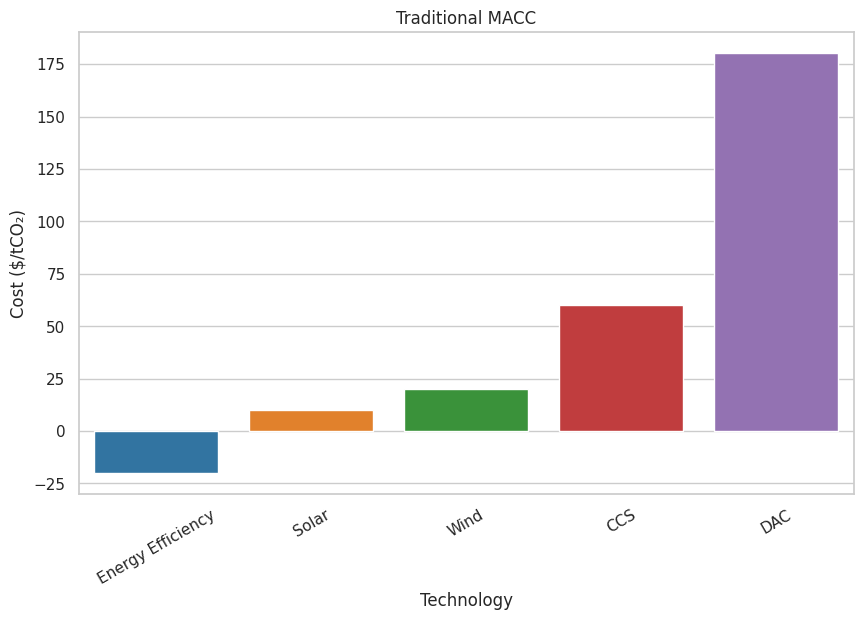

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=summary.sort_values("MeanCost"),
    x="Technology",
    y="MeanCost",
    palette=tech_palette
)

plt.title("Traditional MACC")
plt.ylabel("Cost ($/tCO₂)")
plt.xticks(rotation=30)

plt.show()

### Plot Explanation: Violin MACC Violin Plot

The violin plot displays the distribution of costs for each technology, not just the mean. The wider sections indicate a higher probability density at that cost level. The inner box plot shows the interquartile range and median. This gives a richer understanding of the uncertainty in costs for each technology.

**Business Implication**: It highlights the range and variability of potential costs, allowing for a more nuanced risk assessment. For example, a technology with a low mean cost but a very wide violin shape might be riskier than one with a slightly higher mean but a tighter distribution.

/tmp/ipykernel_4612/653993748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


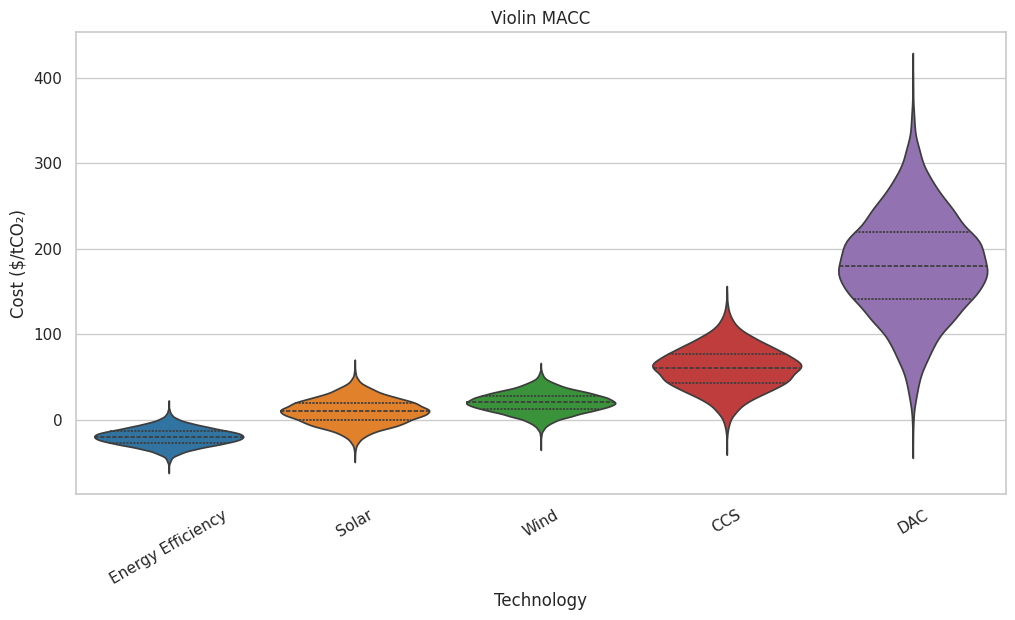

In [10]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=techs,
    x="Technology",
    y="Cost",
    inner="quartile",
    palette=tech_palette
)

plt.title("Violin MACC")
plt.ylabel("Cost ($/tCO₂)")
plt.xticks(rotation=30)

plt.show()

### Plot Explanation: 2D Probabilistic MACC Scatter Plot

This scatter plot visualizes the relationship between abatement (x-axis) and cost (y-axis) for a sample of scenarios for each technology. The color distinguishes between different technologies. This allows us to see how cost and abatement co-vary, revealing potential trade-offs and the spread of outcomes for each technology.

**Business Implication**: This plot is crucial for understanding the uncertainty in both cost and abatement simultaneously. It helps identify technologies that consistently offer high abatement for low cost, or those with significant uncertainty in both metrics, informing strategic choices under uncertainty.

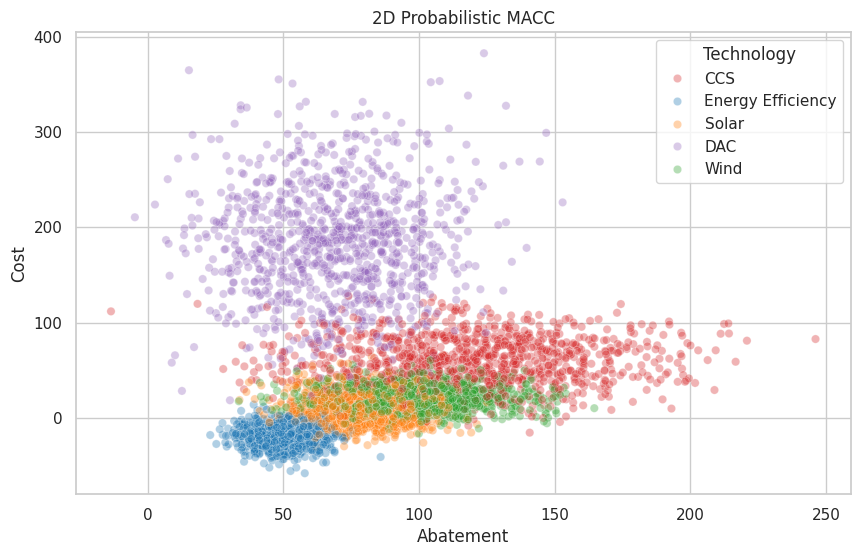

In [11]:
sample = techs.sample(
    min(5000, len(techs)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x="Abatement",
    y="Cost",
    hue="Technology",
    palette=tech_palette,
    alpha=0.35
)

plt.title("2D Probabilistic MACC")

plt.show()

### Plot Explanation: Hourglass MACC Error Bar Plot (P10 / P50 / P90)

The 'Hourglass MACC' uses error bars to show the 10th, 50th (median), and 90th percentile of costs for each technology. This plot provides a concise view of the central tendency (median) and the spread of the costs, offering more information than just the mean.

**Business Implication**: This plot helps decision-makers understand the range of costs they might encounter. The P10 and P90 values provide optimistic and pessimistic cost scenarios, respectively, aiding in financial planning and risk management by outlining the potential best-case and worst-case scenarios.

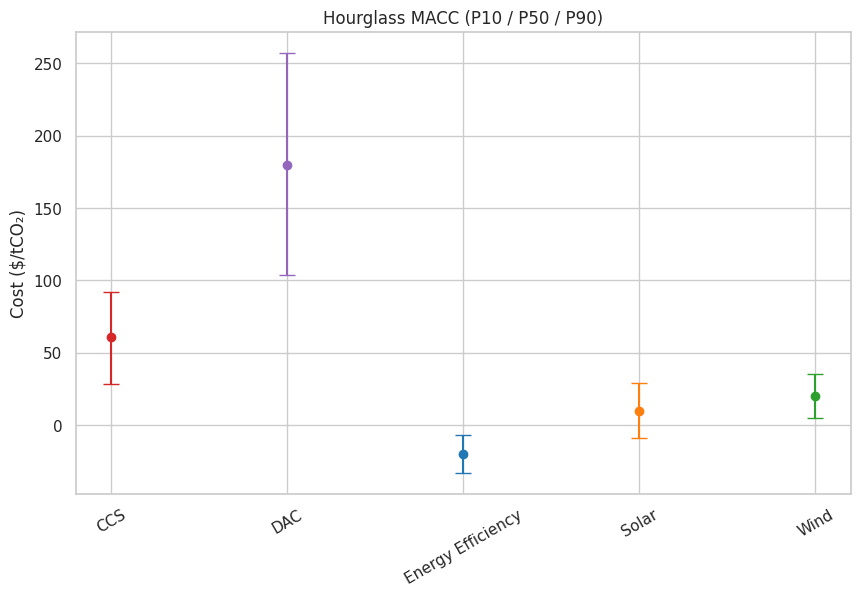

In [12]:
q = (
    techs.groupby("Technology")
    .Cost
    .quantile([0.10, 0.50, 0.90])
    .unstack()
    .reset_index()
)

q["err_low"] = q[0.50] - q[0.10]
q["err_high"] = q[0.90] - q[0.50]

plt.figure(figsize=(10,6))

# Iterate through each technology to assign consistent colors
for idx, tech_name in enumerate(q["Technology"]):
    plt.errorbar(
        x=[q["Technology"].iloc[idx]], # Pass as list for single point
        y=[q[0.50].iloc[idx]],
        yerr=[[q["err_low"].iloc[idx]], [q["err_high"].iloc[idx]]], # yerr needs to be a list of lists for single point
        fmt="o",
        capsize=6,
        color=tech_palette[tech_name] # Assign color from palette
    )

plt.title("Hourglass MACC (P10 / P50 / P90)")
plt.ylabel("Cost ($/tCO₂)")
plt.xticks(rotation=30)

plt.show()

### Plot Explanation: Monte Carlo Portfolio Frontier Scatter Plot

This scatter plot displays the total portfolio cost versus total portfolio abatement across many Monte Carlo scenarios. Each point represents one complete scenario, showing the aggregated outcome if all technologies were implemented under that specific set of uncertainties.

**Business Implication**: This visualization helps to understand the overall uncertainty and potential range of outcomes for the entire portfolio of technologies. It can reveal the 'frontier' of achievable abatement for a given cost, helping in strategic planning and setting realistic targets for overall decarbonization efforts.

In [ ]:
portfolio = (
    techs.groupby("Scenario")
    .agg(
        PortfolioCost=("Cost", "sum"),
        PortfolioAbatement=("Abatement", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=portfolio,
    x="PortfolioAbatement",
    y="PortfolioCost",
    alpha=0.15
)

plt.title("Monte Carlo Portfolio Frontier")

plt.show()

### Plot Explanation: Forest Plot (95% Confidence Interval)

This 'Forest Plot' shows the mean cost for each technology along with its 95% confidence interval. The horizontal lines represent the confidence intervals, and the dot is the mean. The vertical dashed line at zero helps identify technologies that are confidently net-negative (saving money) or net-positive (costing money).

**Business Implication**: Confidence intervals provide a statistical measure of the precision of the estimated mean cost. A narrower interval indicates higher confidence in the mean estimate. This plot is essential for making robust decisions, especially when comparing technologies with similar mean costs but different levels of uncertainty, by showing the statistical reliability of the cost estimates.

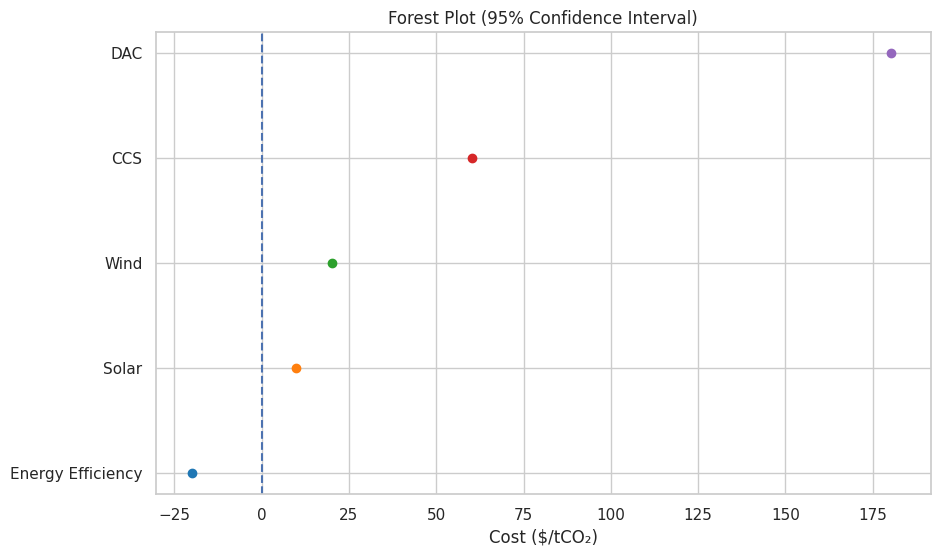

In [13]:
summary_ci = (
    techs.groupby("Technology")["Cost"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_ci["SEM"] = (
    summary_ci["std"]
    / np.sqrt(summary_ci["count"])
)

summary_ci["CriticalValue"] = summary_ci["count"].apply(
    lambda n: stats.t.ppf(0.975, n - 1)
)

summary_ci["Margin"] = (
    summary_ci["SEM"]
    * summary_ci["CriticalValue"]
)

summary_ci["Lower"] = (
    summary_ci["mean"]
    - summary_ci["Margin"]
)

summary_ci["Upper"] = (
    summary_ci["mean"]
    + summary_ci["Margin"]
)

summary_ci = summary_ci.sort_values("mean")

plt.figure(figsize=(10,6))

# Iterate through each technology to assign consistent colors
for idx, tech_name in enumerate(summary_ci["Technology"]):
    plt.errorbar(
        x=summary_ci["mean"].iloc[idx],
        y=summary_ci["Technology"].iloc[idx],
        xerr=[
            [summary_ci["mean"].iloc[idx] - summary_ci["Lower"].iloc[idx]], # Pass as list of lists for single point
            [summary_ci["Upper"].iloc[idx] - summary_ci["mean"].iloc[idx]]
        ],
        fmt="o",
        color=tech_palette[tech_name] # Assign color from palette
    )

plt.axvline(0, linestyle="--")

plt.title("Forest Plot (95% Confidence Interval)")
plt.xlabel("Cost ($/tCO₂)")

plt.show()